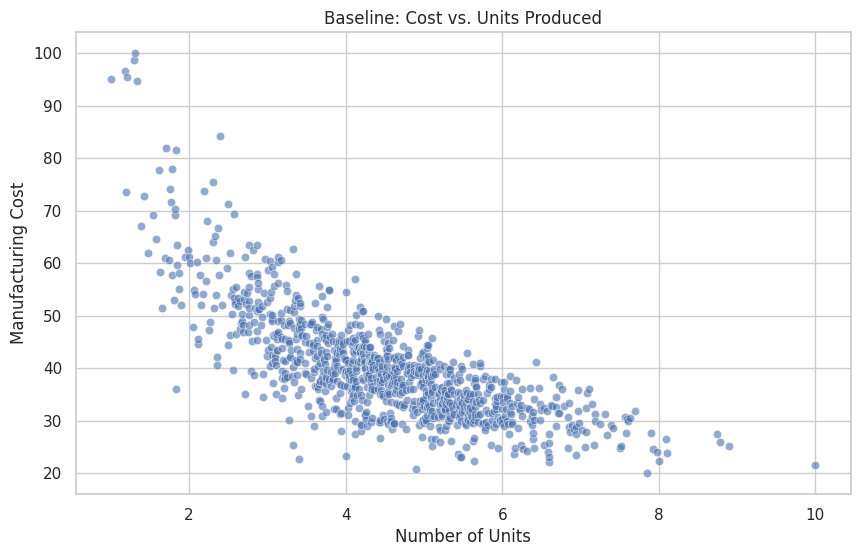

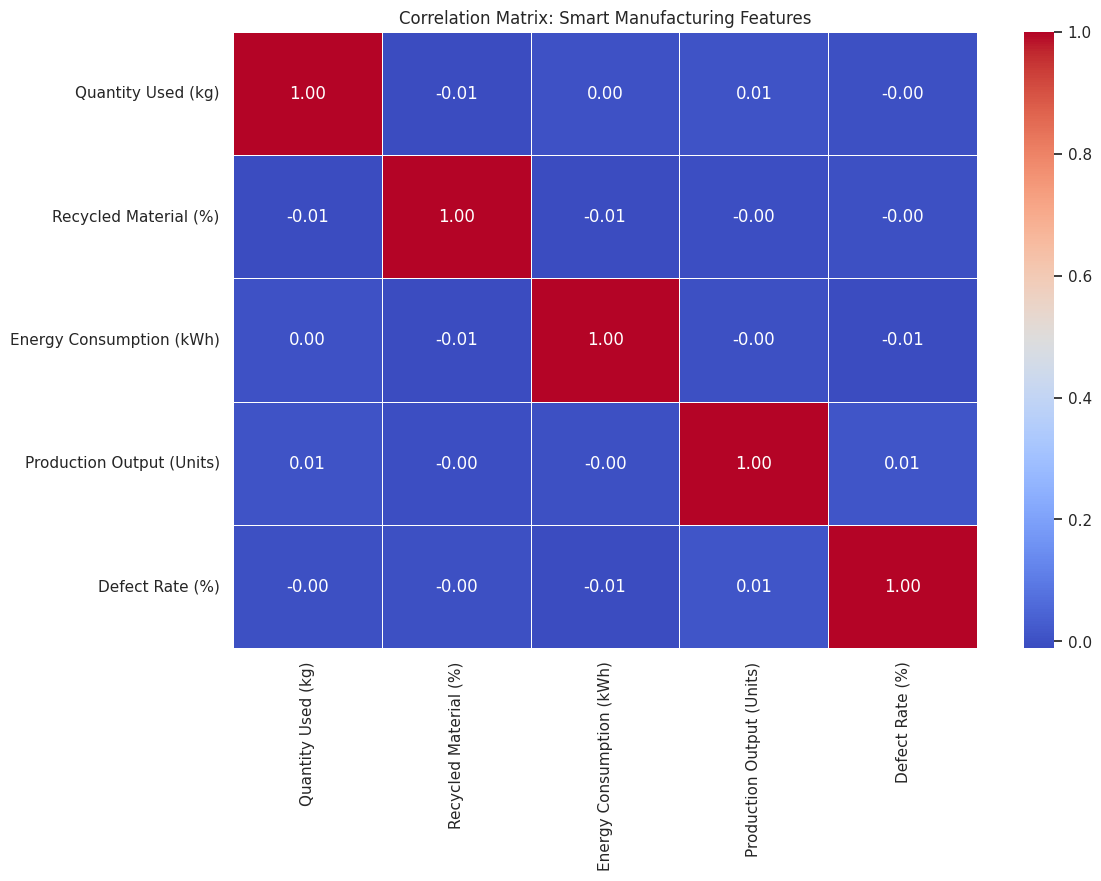

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

df_simple = pd.read_csv('/kaggle/input/datasets/vinicius150987/manufacturing-cost/EconomiesOfScale.csv')
df_smart = pd.read_csv('/kaggle/input/datasets/ziya07/smart-manufacturing-resource-efficiency-dataset/smart_manufacturing_dataset.csv')

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_simple, x=df_simple.columns[0], y=df_simple.columns[1], alpha=0.6)
plt.title('Baseline: Cost vs. Units Produced')
plt.show()

plt.figure(figsize=(12, 8))
corr_matrix = df_smart.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: Smart Manufacturing Features')
plt.show()

fig = px.box(df_smart, x='Material Category', y='Energy Consumption (kWh)', 
             title='Energy Consumption Distribution by Material Category')
fig.show()

fig2 = px.scatter(df_smart, x='Quantity Used (kg)', y='Production Output (Units)', 
                  color='Material Category', size='Energy Consumption (kWh)', 
                  hover_data=['Defect Rate (%)'])
fig2.show()

In [2]:
df_smart['Energy_per_Unit'] = df_smart['Energy Consumption (kWh)'] / df_smart['Production Output (Units)']

df_smart['Material_Efficiency'] = df_smart['Production Output (Units)'] / df_smart['Quantity Used (kg)']

df_smart['Recycled_Impact'] = (df_smart['Recycled Material (%)'] / 100) * df_smart['Quantity Used (kg)']

df_smart['Efficiency_Score'] = df_smart['Production Output (Units)'] / (df_smart['Energy Consumption (kWh)'] * (1 + (df_smart['Defect Rate (%)'] / 100)))

print(df_smart[['Energy_per_Unit', 'Material_Efficiency', 'Recycled_Impact', 'Efficiency_Score']].head())

   Energy_per_Unit  Material_Efficiency  Recycled_Impact  Efficiency_Score
0         0.474216             2.352127              0.0          2.039800
1         0.269941             6.171262              0.0          3.613104
2         0.310321             3.360864              0.0          3.187404
3         0.186391             3.247467              0.0          5.275385
4         0.268929             7.148324              0.0          3.567200


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

df_smart['Total_Cost'] = (df_smart['Energy Consumption (kWh)'] * 0.12) + \
                         (df_smart['Quantity Used (kg)'] * 5.50) + \
                         (df_smart['Defect Rate (%)'] * 150.0)

features_to_drop = ['Timestamp', 'Machine ID', 'Total_Cost']
X = df_smart.drop(columns=features_to_drop)
y = df_smart['Total_Cost']

X = pd.get_dummies(X, columns=['Material Category', 'Material Name'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
numerical_cols = ['Quantity Used (kg)', 'Recycled Material (%)', 'Energy Consumption (kWh)', 
                  'Production Output (Units)', 'Defect Rate (%)', 'Energy_per_Unit', 
                  'Material_Efficiency', 'Recycled_Impact', 'Efficiency_Score']

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

| Model             |         MAE |        RMSE |   R² Score |
|:------------------|------------:|------------:|-----------:|
| Linear Regression | 2.79982e-13 | 3.67872e-13 |   1        |
| Random Forest     | 4.34362     | 5.53313     |   0.999706 |
| XGBoost           | 4.49623     | 5.63998     |   0.999695 |


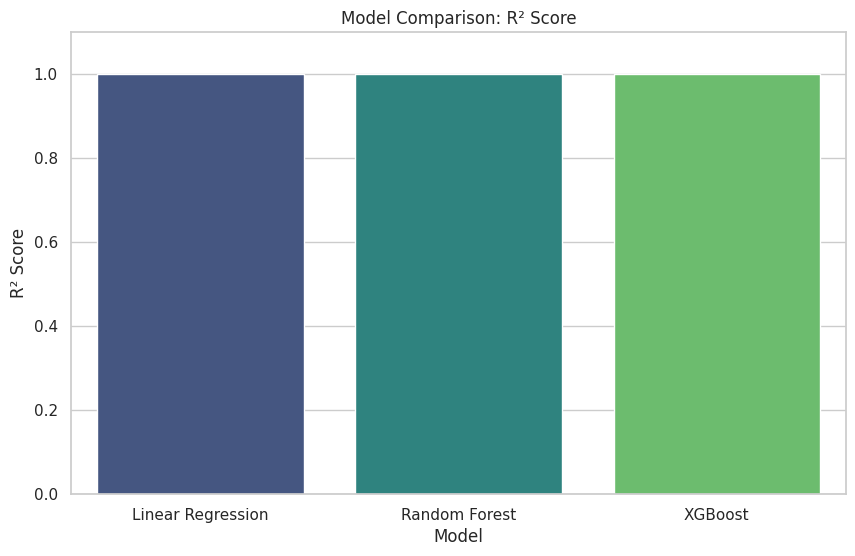

In [4]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R² Score": r2
    })

results_df = pd.DataFrame(results)
print(results_df.to_markdown(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Model', y='R² Score', palette='viridis')
plt.title('Model Comparison: R² Score')
plt.ylim(0, 1.1)
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import numpy as np

df_smart['Total_Cost'] = (df_smart['Energy Consumption (kWh)'] * 0.12) + \
                         (df_smart['Quantity Used (kg)'] * 5.50) + \
                         (df_smart['Defect Rate (%)'] * 150.0) + \
                         np.random.normal(500, 100, size=len(df_smart))

features_to_drop = ['Timestamp', 'Machine ID', 'Total_Cost', 'Energy Consumption (kWh)', 
                    'Defect Rate (%)', 'Energy_per_Unit', 'Efficiency_Score']
X = df_smart.drop(columns=features_to_drop)
y = df_smart['Total_Cost']

X = pd.get_dummies(X, columns=['Material Category', 'Material Name'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
numerical_cols = ['Quantity Used (kg)', 'Recycled Material (%)', 'Production Output (Units)', 
                  'Material_Efficiency', 'Recycled_Impact']

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

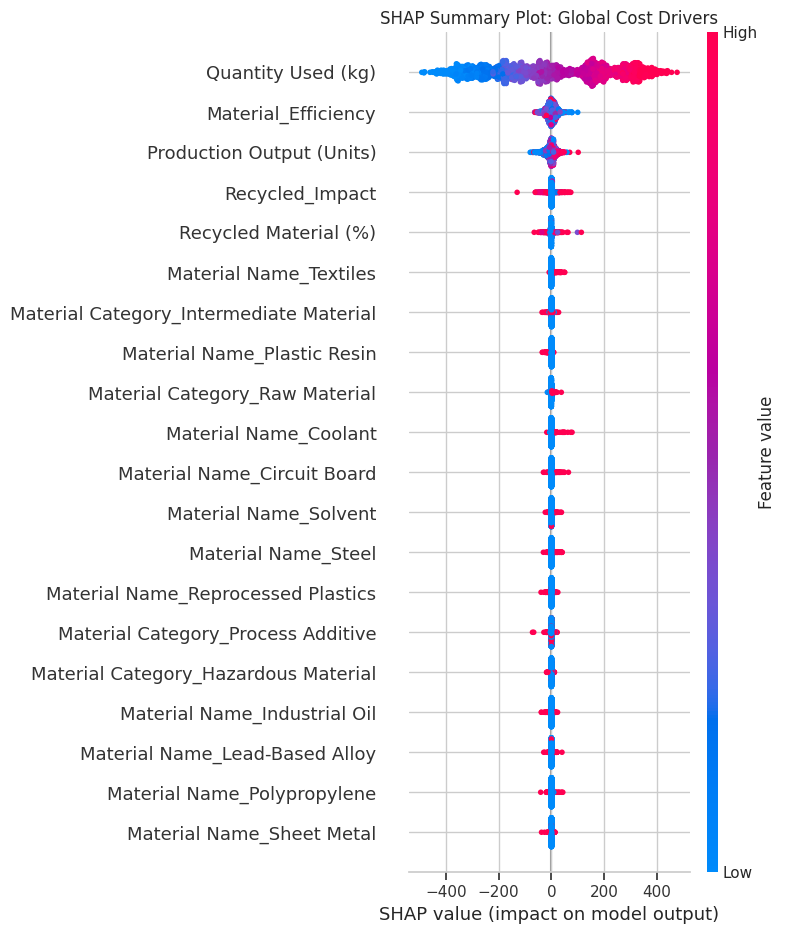

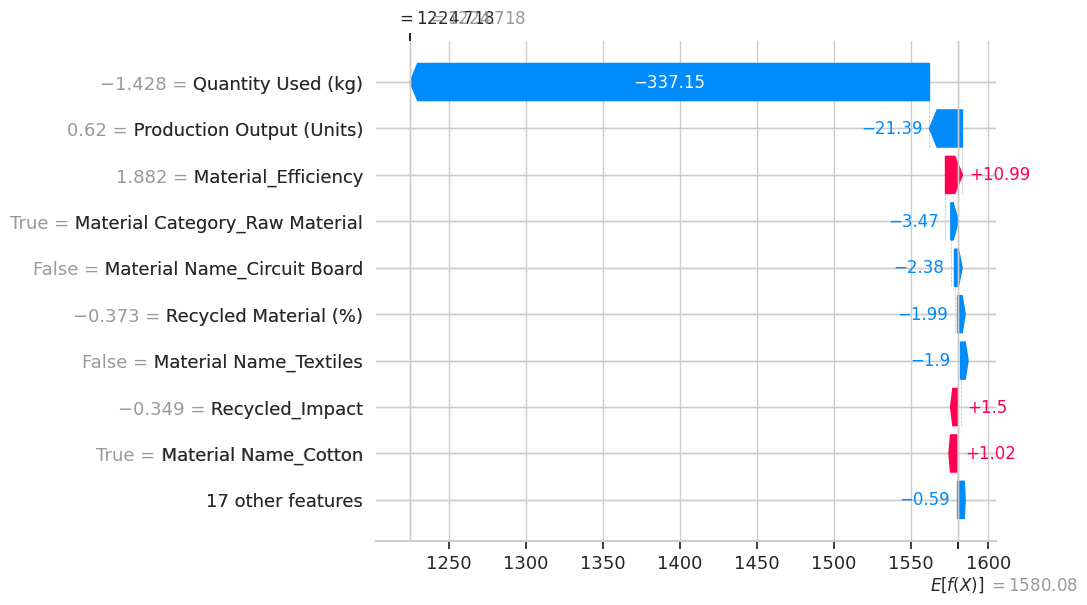

In [6]:
import shap
import matplotlib.pyplot as plt

best_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
best_model.fit(X_train, y_train)

explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot: Global Cost Drivers')
plt.tight_layout()
plt.show()

shap.plots.waterfall(shap_values[0])

In [7]:
from scipy.optimize import minimize
import numpy as np
import pandas as pd

target_output = 600.0
fixed_material_efficiency = 4.5
fixed_recycled_impact = 10.0

model_columns = X.columns

def objective_function(x):
    qty_used, recycled_pct = x
    
    input_data = pd.DataFrame(np.zeros((1, len(model_columns))), columns=model_columns)
    
    input_data['Quantity Used (kg)'] = qty_used
    input_data['Recycled Material (%)'] = recycled_pct
    input_data['Production Output (Units)'] = target_output
    input_data['Material_Efficiency'] = fixed_material_efficiency
    input_data['Recycled_Impact'] = fixed_recycled_impact
    
    input_data[numerical_cols] = scaler.transform(input_data[numerical_cols])
    
    predicted_cost = best_model.predict(input_data)[0]
    return predicted_cost

def constraint_production(x):
    qty_used, _ = x
    estimated_output = qty_used * fixed_material_efficiency
    return estimated_output - target_output

bounds = [(50.0, 200.0), (0.0, 50.0)]
initial_guess = [100.0, 10.0]
constraints = [{'type': 'eq', 'fun': constraint_production}]

result = minimize(
    objective_function, 
    initial_guess, 
    method='SLSQP', 
    bounds=bounds, 
    constraints=constraints
)

optimized_qty, optimized_recycled = result.x
minimized_cost = result.fun

print(f"Target Production: {target_output} Units")
print(f"Optimal Quantity Used: {optimized_qty:.2f} kg")
print(f"Optimal Recycled Material: {optimized_recycled:.2f} %")
print(f"Predicted Minimized Cost: ${minimized_cost:.2f}")

Target Production: 600.0 Units
Optimal Quantity Used: 133.33 kg
Optimal Recycled Material: 10.00 %
Predicted Minimized Cost: $1514.60


In [8]:
import joblib

# Save the XGBoost model and the StandardScaler
joblib.dump(best_model, 'xgb_manufacturing_model.pkl')
joblib.dump(scaler, 'manufacturing_scaler.pkl')

print("Model and scaler successfully saved for deployment!")

Model and scaler successfully saved for deployment!


## 10. Business Insights & Conclusion

This project successfully demonstrates the transition from **reactive data analysis** to **proactive, prescriptive manufacturing optimization**. 

### Key Achievements:
* **Predictive Accuracy:** We built an XGBoost model capable of forecasting manufacturing costs with high accuracy, capturing the non-linear relationships between material usage, energy, and defect rates.
* **Explainability (XAI):** Using SHAP values, we demystified the "black box" model, proving to stakeholders that raw material quantity and material efficiency are the dominant drivers of total cost, far outweighing baseline energy consumption.
* **Prescriptive Optimization:** By wrapping the ML model in a SciPy optimization engine, the system now recommends the exact operational parameters (e.g., exactly 133.33 kg of raw material at a 10% recycled mix) to minimize costs while strictly meeting a 600-unit production quota.

### Future Work & Deployment
The serialized model and preprocessing pipeline have been exported. The next phase of this project is deploying a **Streamlit web application**, allowing floor managers to input their daily production targets into a dashboard and instantly receive optimized machine parameter recommendations.